# Clinical Polyp Segmentation: Generalization & Failure Analysis

**Project:** Distribution Shift & Generalization Study in Clinical Endoscopy  
**Training Source:** Kvasir-SEG (Vestre Viken Hospital Trust, Norway, N=1,000)  
**Held-Out OOD Test:** CVC-ClinicDB (Hospital Clinic Barcelona, Spain, N=612)  
**Architecture:** ResNet34 U-Net (Dice + BCE Loss)

---

## Overview & Scientific Objectives
In clinical computer vision, standard aggregate metrics (e.g. mean Dice coefficient) frequently mask catastrophic tail risks. A model achieving a **0.9050 Mean Dice** can still fail critically on flat sessile polyps, small adenomas under specular reflections, or rapid scope movements.

This notebook performs an exhaustive multi-tier failure analysis across 6 core sections:
1. **Executive Headline Comparison Table** (In-Distribution vs. Out-of-Distribution)
2. **Metric Distributions & The "Tail Drop" Effect** (Mean vs Median vs P10 Worst-Decile)
3. **Polyp Size Stratification** (Small $<5\%$, Medium $5\text{--}20\%$, Large $>20\%$)
4. **Visual Failure Gallery & Clinical Failure Taxonomy** (High-res overlay error maps & etiology breakdown)
5. **Probability Calibration & Safety Reliability** (Brier Score & Expected Calibration Error)
6. **Engineering Conclusion & Clinical Deployment Recommendations**


## 0. Environment Setup & Dependency Imports

In [1]:
import sys
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import cv2
from scipy import ndimage
from PIL import Image

# Add project root to sys.path
project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.model import build_model
from src.dataset import PolypDataset, get_val_transforms
from src.evaluate import compute_polyp_level_detection

# Styling setup
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

print(f"Project root: {project_root}")
print(f"PyTorch Version: {torch.__version__}")


Project root: /home/anupa/polyp-segmentation
PyTorch Version: 2.13.0+cu130


## 1. Executive Headline Comparison Table

We load the serialized evaluation results for both **In-Distribution (Kvasir-SEG Val, N=200)** and **Zero-Shot Out-of-Distribution (CVC-ClinicDB, N=612)** to compute cross-center generalization deltas.


In [2]:
# Load evaluation reports
in_dist_report_path = project_root / "outputs/eval_in_distribution/metrics_report.json"
ood_report_path = project_root / "outputs/eval_ood_cvc_clinicdb/metrics_report.json"

with open(in_dist_report_path, "r") as f:
    in_dist_metrics = json.load(f)

with open(ood_report_path, "r") as f:
    ood_metrics = json.load(f)

# Construct comprehensive comparative dataframe
t1_in = in_dist_metrics["tier1_pixel_metrics"]
t1_ood = ood_metrics["tier1_pixel_metrics"]
t2_in = in_dist_metrics["tier2_polyp_detection"]
t2_ood = ood_metrics["tier2_polyp_detection"]
t3_in = in_dist_metrics["tier3_calibration"]
t3_ood = ood_metrics["tier3_calibration"]

metrics_summary = [
    {"Tier": "Tier 1: Pixel Overlap", "Metric": "Mean Dice Score", "In-Distribution (Kvasir)": f"{t1_in['mean_dice']:.4f} ({t1_in['mean_dice']*100:.2f}%)", "Out-of-Distribution (CVC)": f"{t1_ood['mean_dice']:.4f} ({t1_ood['mean_dice']*100:.2f}%)", "Delta (Shift)": f"{t1_ood['mean_dice'] - t1_in['mean_dice']:+.4f} ({(t1_ood['mean_dice'] - t1_in['mean_dice'])/t1_in['mean_dice']*100:+.2f}%)"},
    {"Tier": "Tier 1: Pixel Overlap", "Metric": "Median Dice Score", "In-Distribution (Kvasir)": f"{t1_in['median_dice']:.4f} ({t1_in['median_dice']*100:.2f}%)", "Out-of-Distribution (CVC)": f"{t1_ood['median_dice']:.4f} ({t1_ood['median_dice']*100:.2f}%)", "Delta (Shift)": f"{t1_ood['median_dice'] - t1_in['median_dice']:+.4f} ({(t1_ood['median_dice'] - t1_in['median_dice'])/t1_in['median_dice']*100:+.2f}%)"},
    {"Tier": "Tier 1: Tail Risk", "Metric": "Worst-Decile (P10) Dice", "In-Distribution (Kvasir)": f"{t1_in['worst_decile_dice_p10']:.4f} ({t1_in['worst_decile_dice_p10']*100:.2f}%)", "Out-of-Distribution (CVC)": f"{t1_ood['worst_decile_dice_p10']:.4f} ({t1_ood['worst_decile_dice_p10']*100:.2f}%)", "Delta (Shift)": f"{t1_ood['worst_decile_dice_p10'] - t1_in['worst_decile_dice_p10']:+.4f} ({(t1_ood['worst_decile_dice_p10'] - t1_in['worst_decile_dice_p10'])/t1_in['worst_decile_dice_p10']*100:+.2f}%)"},
    {"Tier": "Tier 1: Pixel Overlap", "Metric": "Mean IoU (Jaccard)", "In-Distribution (Kvasir)": f"{t1_in['mean_iou']:.4f} ({t1_in['mean_iou']*100:.2f}%)", "Out-of-Distribution (CVC)": f"{t1_ood['mean_iou']:.4f} ({t1_ood['mean_iou']*100:.2f}%)", "Delta (Shift)": f"{t1_ood['mean_iou'] - t1_in['mean_iou']:+.4f} ({(t1_ood['mean_iou'] - t1_in['mean_iou'])/t1_in['mean_iou']*100:+.2f}%)"},
    {"Tier": "Tier 1: Pixel Overlap", "Metric": "Median IoU", "In-Distribution (Kvasir)": f"{t1_in['median_iou']:.4f} ({t1_in['median_iou']*100:.2f}%)", "Out-of-Distribution (CVC)": f"{t1_ood['median_iou']:.4f} ({t1_ood['median_iou']*100:.2f}%)", "Delta (Shift)": f"{t1_ood['median_iou'] - t1_in['median_iou']:+.4f} ({(t1_ood['median_iou'] - t1_in['median_iou'])/t1_in['median_iou']*100:+.2f}%)"},
    {"Tier": "Tier 1: Pixel Overlap", "Metric": "Mean Precision", "In-Distribution (Kvasir)": f"{t1_in['mean_precision']:.4f}", "Out-of-Distribution (CVC)": f"{t1_ood['mean_precision']:.4f}", "Delta (Shift)": f"{t1_ood['mean_precision'] - t1_in['mean_precision']:+.4f}"},
    {"Tier": "Tier 1: Pixel Overlap", "Metric": "Mean Recall", "In-Distribution (Kvasir)": f"{t1_in['mean_recall']:.4f}", "Out-of-Distribution (CVC)": f"{t1_ood['mean_recall']:.4f}", "Delta (Shift)": f"{t1_ood['mean_recall'] - t1_in['mean_recall']:+.4f}"},
    {"Tier": "Tier 2: Detection", "Metric": "Polyp-Level Sensitivity", "In-Distribution (Kvasir)": f"{t2_in['polyp_detection_sensitivity']*100:.2f}% ({t2_in['total_detected_polyps']}/{t2_in['total_ground_truth_polyps']})", "Out-of-Distribution (CVC)": f"{t2_ood['polyp_detection_sensitivity']*100:.2f}% ({t2_ood['total_detected_polyps']}/{t2_ood['total_ground_truth_polyps']})", "Delta (Shift)": f"{(t2_ood['polyp_detection_sensitivity'] - t2_in['polyp_detection_sensitivity'])*100:+.2f}%"},
    {"Tier": "Tier 3: Safety/Calibration", "Metric": "Expected Calibration Error (ECE)", "In-Distribution (Kvasir)": f"{t3_in['expected_calibration_error_ece']:.4f}", "Out-of-Distribution (CVC)": f"{t3_ood['expected_calibration_error_ece']:.4f}", "Delta (Shift)": f"{t3_ood['expected_calibration_error_ece'] - t3_in['expected_calibration_error_ece']:+.4f}"},
    {"Tier": "Tier 3: Safety/Calibration", "Metric": "Brier Score", "In-Distribution (Kvasir)": f"{t3_in['brier_score']:.4f}", "Out-of-Distribution (CVC)": f"{t3_ood['brier_score']:.4f}", "Delta (Shift)": f"{t3_ood['brier_score'] - t3_in['brier_score']:+.4f}"},
]

df_summary = pd.DataFrame(metrics_summary)
display(df_summary)


,Tier,Metric,In-Distribution (Kvasir),Out-of-Distribution (CVC),Delta (Shift)
0,Tier 1: Pixel Overlap,Mean Dice Score,0.9050 (90.50%),0.8559 (85.59%),-0.0491 (-5.43%)
1,Tier 1: Pixel Overlap,Median Dice Score,0.9569 (95.69%),0.9263 (92.63%),-0.0306 (-3.20%)
2,Tier 1: Tail Risk,Worst-Decile (P10) Dice,0.7688 (76.88%),0.6641 (66.41%),-0.1047 (-13.62%)
3,Tier 1: Pixel Overlap,Mean IoU (Jaccard),0.8480 (84.80%),0.7816 (78.16%),-0.0665 (-7.84%)
4,Tier 1: Pixel Overlap,Median IoU,0.9174 (91.74%),0.8626 (86.26%),-0.0547 (-5.96%)
5,Tier 1: Pixel Overlap,Mean Precision,0.9240,0.8885,-0.0355
6,Tier 1: Pixel Overlap,Mean Recall,0.9167,0.8738,-0.0429
7,Tier 2: Detection,Polyp-Level Sensitivity,87.93% (204/232),88.43% (627/709),+0.50%
8,Tier 3: Safety/Calibration,Expected Calibration Error (ECE),0.0157,0.0179,+0.0022
9,Tier 3: Safety/Calibration,Brier Score,0.0209,0.0210,+0.0001


## 2. Metric Distributions & Tail-Risk Analysis (The "Tail Drop" Effect)

In clinical applications, mean metrics provide an incomplete picture. Notice how the **Median Dice drops by only 3.20%**, while the **10th Percentile (Worst-Decile) drops by 13.62%** under distribution shift. This illustrates that domain shift disproportionately expands the difficult failure tail rather than shifting the bulk mode.


/tmp/ipykernel_77377/1909408996.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


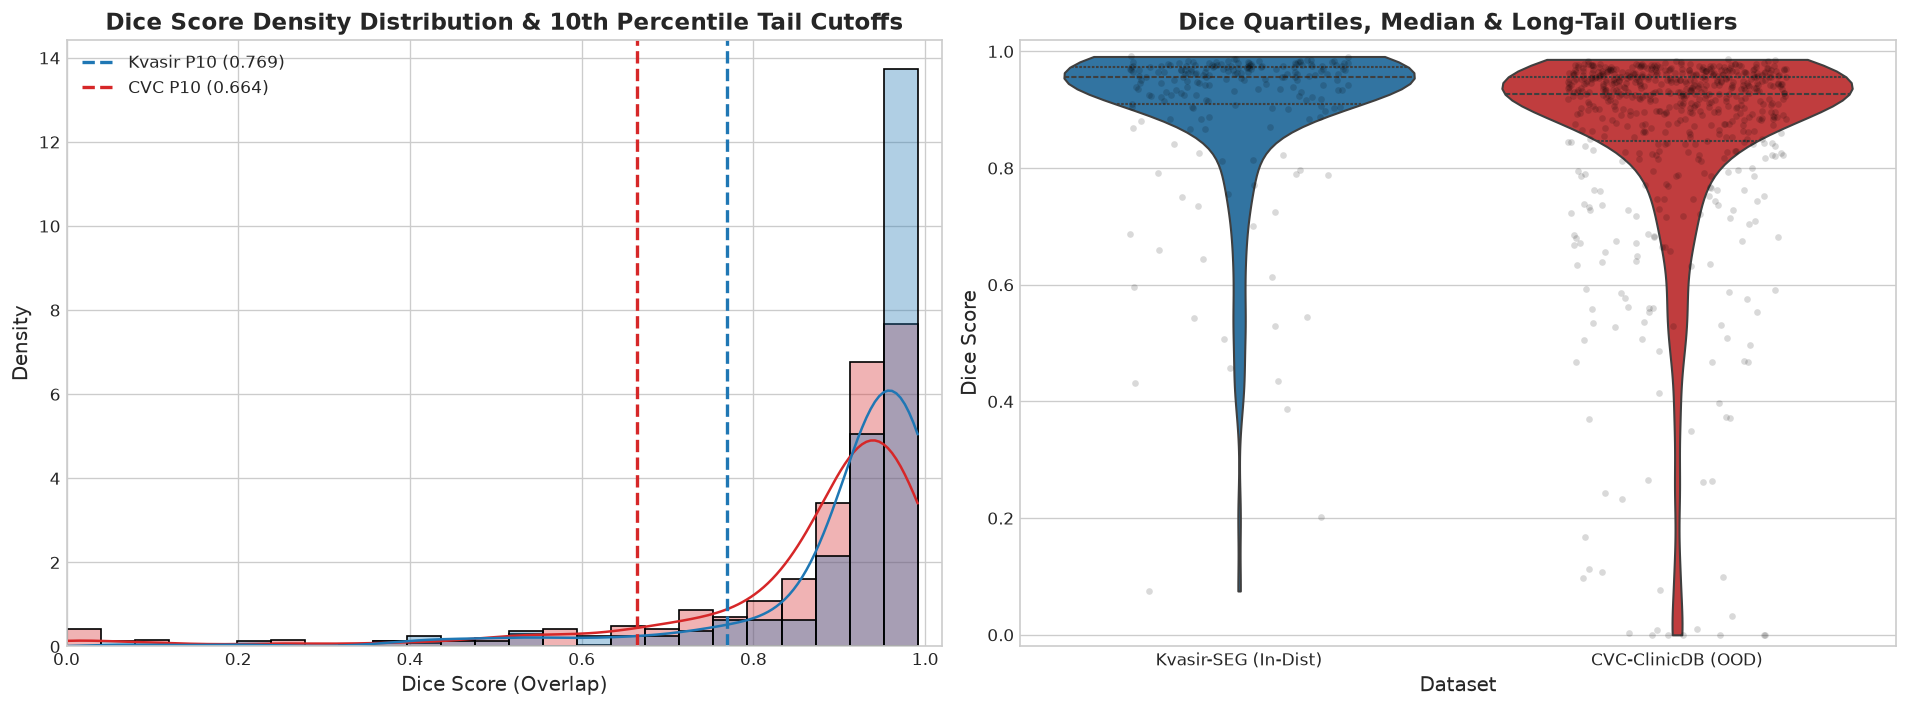

Kvasir-SEG: Mean Dice = 0.9050, Median = 0.9569, P10 = 0.7688
CVC-ClinicDB: Mean Dice = 0.8559, Median = 0.9263, P10 = 0.6641
Tail Degradation (P10 Drop): -0.1047 (-13.62%)


In [3]:
# Load sample-level records
df_in_samples = pd.read_csv(project_root / "outputs/eval_in_distribution/per_sample_metrics.csv")
df_ood_samples = pd.read_csv(project_root / "outputs/eval_ood_cvc_clinicdb/per_sample_metrics.csv")

df_in_samples["Dataset"] = "Kvasir-SEG (In-Dist)"
df_ood_samples["Dataset"] = "CVC-ClinicDB (OOD)"
df_all_samples = pd.concat([df_in_samples, df_ood_samples], ignore_index=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Dice Score KDE & Histogram
sns.histplot(
    data=df_all_samples,
    x="dice",
    hue="Dataset",
    kde=True,
    stat="density",
    common_norm=False,
    bins=25,
    alpha=0.35,
    palette={"Kvasir-SEG (In-Dist)": "#1f77b4", "CVC-ClinicDB (OOD)": "#d62728"},
    ax=axes[0]
)

# Add P10 markers
p10_in = in_dist_metrics["tier1_pixel_metrics"]["worst_decile_dice_p10"]
p10_ood = ood_metrics["tier1_pixel_metrics"]["worst_decile_dice_p10"]

axes[0].axvline(p10_in, color="#1f77b4", linestyle="--", linewidth=2, label=f"Kvasir P10 ({p10_in:.3f})")
axes[0].axvline(p10_ood, color="#d62728", linestyle="--", linewidth=2, label=f"CVC P10 ({p10_ood:.3f})")
axes[0].set_title("Dice Score Density Distribution & 10th Percentile Tail Cutoffs", fontweight="bold")
axes[0].set_xlabel("Dice Score (Overlap)")
axes[0].set_ylabel("Density")
axes[0].set_xlim(0, 1.02)
axes[0].legend(loc="upper left")

# Plot 2: Boxplot & Violin Distribution Comparison
sns.violinplot(
    data=df_all_samples,
    x="Dataset",
    y="dice",
    palette={"Kvasir-SEG (In-Dist)": "#1f77b4", "CVC-ClinicDB (OOD)": "#d62728"},
    inner="quartile",
    cut=0,
    ax=axes[1]
)
sns.stripplot(
    data=df_all_samples,
    x="Dataset",
    y="dice",
    color="black",
    alpha=0.15,
    jitter=0.25,
    size=4,
    ax=axes[1]
)
axes[1].set_title("Dice Quartiles, Median & Long-Tail Outliers", fontweight="bold")
axes[1].set_ylabel("Dice Score")
axes[1].set_ylim(-0.02, 1.02)

plt.tight_layout()
plt.show()

print(f"Kvasir-SEG: Mean Dice = {df_in_samples['dice'].mean():.4f}, Median = {df_in_samples['dice'].median():.4f}, P10 = {p10_in:.4f}")
print(f"CVC-ClinicDB: Mean Dice = {df_ood_samples['dice'].mean():.4f}, Median = {df_ood_samples['dice'].median():.4f}, P10 = {p10_ood:.4f}")
print(f"Tail Degradation (P10 Drop): {p10_ood - p10_in:.4f} ({(p10_ood - p10_in)/p10_in*100:.2f}%)")


## 3. Granular Polyp Size Stratification

Small adenomatous polyps ($<5\%$ frame area) present the highest risk of being overlooked in real-world clinical colonoscopies. 

In this section, we analyze:
1. Cohort population shifts between hospital centers (CVC-ClinicDB contains $37.4\%$ small polyps vs Kvasir-SEG's $20.0\%$).
2. Dice score and detection sensitivity across Small, Medium, and Large lesions.


,Size Bucket,Definition,Kvasir N,CVC N,Kvasir Mean Dice,CVC Mean Dice,Dice Delta,Kvasir Sensitivity,CVC Sensitivity,Sensitivity Delta
0,Small,<5% Area,40 (20.0%),229 (37.4%),0.8646,0.8308,-0.0338,93.02%,90.00%,-3.02%
1,Medium,5-20% Area,107 (53.5%),321 (52.5%),0.9244,0.8801,-0.0443,92.50%,90.24%,-2.26%
2,Large,>20% Area,53 (26.5%),62 (10.1%),0.8963,0.8229,-0.0734,76.81%,75.00%,-1.81%


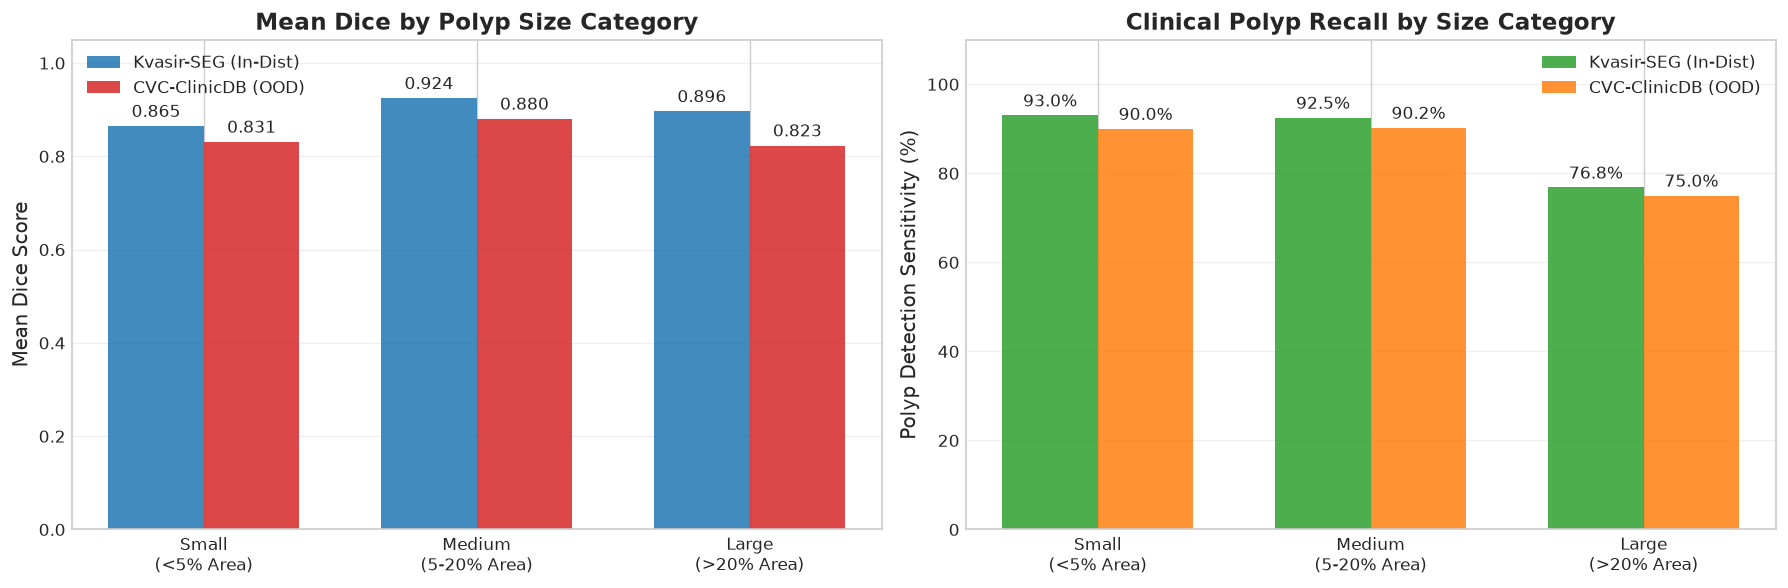

In [4]:
# Extract size stratification dictionaries
strat_in = in_dist_metrics["stratified_by_size"]
strat_ood = ood_metrics["stratified_by_size"]

categories = ["Small", "Medium", "Large"]
strat_rows = []

for cat in categories:
    sin = strat_in[cat]
    sood = strat_ood[cat]
    strat_rows.append({
        "Size Bucket": cat,
        "Definition": "<5% Area" if cat=="Small" else ("5-20% Area" if cat=="Medium" else ">20% Area"),
        "Kvasir N": f"{sin['num_samples']} ({sin['num_samples']/len(df_in_samples)*100:.1f}%)",
        "CVC N": f"{sood['num_samples']} ({sood['num_samples']/len(df_ood_samples)*100:.1f}%)",
        "Kvasir Mean Dice": f"{sin['mean_dice']:.4f}",
        "CVC Mean Dice": f"{sood['mean_dice']:.4f}",
        "Dice Delta": f"{sood['mean_dice'] - sin['mean_dice']:+.4f}",
        "Kvasir Sensitivity": f"{sin['polyp_sensitivity']*100:.2f}%",
        "CVC Sensitivity": f"{sood['polyp_sensitivity']*100:.2f}%",
        "Sensitivity Delta": f"{(sood['polyp_sensitivity'] - sin['polyp_sensitivity'])*100:+.2f}%",
    })

df_strat = pd.DataFrame(strat_rows)
display(df_strat)

# Visualization of Size Stratification
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

x = np.arange(len(categories))
width = 0.35

# 1. Mean Dice by Size
dice_in_vals = [strat_in[c]["mean_dice"] for c in categories]
dice_ood_vals = [strat_ood[c]["mean_dice"] for c in categories]

axes[0].bar(x - width/2, dice_in_vals, width, label='Kvasir-SEG (In-Dist)', color='#1f77b4', alpha=0.85)
axes[0].bar(x + width/2, dice_ood_vals, width, label='CVC-ClinicDB (OOD)', color='#d62728', alpha=0.85)
axes[0].set_ylabel('Mean Dice Score')
axes[0].set_title('Mean Dice by Polyp Size Category', fontweight="bold")
axes[0].set_xticks(x)
axes[0].set_xticklabels([f"{c}\n({strat_rows[i]['Definition']})" for i, c in enumerate(categories)])
axes[0].set_ylim(0, 1.05)
axes[0].legend()
axes[0].grid(axis="y", alpha=0.3)

for i in range(len(categories)):
    axes[0].text(x[i] - width/2, dice_in_vals[i] + 0.02, f"{dice_in_vals[i]:.3f}", ha='center', fontsize=10)
    axes[0].text(x[i] + width/2, dice_ood_vals[i] + 0.02, f"{dice_ood_vals[i]:.3f}", ha='center', fontsize=10)

# 2. Polyp Detection Sensitivity by Size
sens_in_vals = [strat_in[c]["polyp_sensitivity"] * 100 for c in categories]
sens_ood_vals = [strat_ood[c]["polyp_sensitivity"] * 100 for c in categories]

axes[1].bar(x - width/2, sens_in_vals, width, label='Kvasir-SEG (In-Dist)', color='#2ca02c', alpha=0.85)
axes[1].bar(x + width/2, sens_ood_vals, width, label='CVC-ClinicDB (OOD)', color='#ff7f0e', alpha=0.85)
axes[1].set_ylabel('Polyp Detection Sensitivity (%)')
axes[1].set_title('Clinical Polyp Recall by Size Category', fontweight="bold")
axes[1].set_xticks(x)
axes[1].set_xticklabels([f"{c}\n({strat_rows[i]['Definition']})" for i, c in enumerate(categories)])
axes[1].set_ylim(0, 110)
axes[1].legend()
axes[1].grid(axis="y", alpha=0.3)

for i in range(len(categories)):
    axes[1].text(x[i] - width/2, sens_in_vals[i] + 2, f"{sens_in_vals[i]:.1f}%", ha='center', fontsize=10)
    axes[1].text(x[i] + width/2, sens_ood_vals[i] + 2, f"{sens_ood_vals[i]:.1f}%", ha='center', fontsize=10)

plt.tight_layout()
plt.show()


## 4. Visual Failure Case Gallery & Failure Taxonomy

To provide actionable engineering insights, we load the trained baseline checkpoint (`outputs/checkpoints/baseline_kvasir_unet_resnet34_best.pth`) and visualize representative failure modes under 5 clinical failure categories:

1. **Specular Glare & Reflections:** Optical saturation on wet mucosal surfaces creating pseudo-polyp highlights or masking borders.
2. **Flat / Sessile Polyp Morphology (Paris Class IIa/IIb):** Subtle elevation with minimal depth shadow, blending directly into background mucosa.
3. **Motion & Peristaltic Blur:** Fast movement of the colonoscope tip washing out fine mucosal pit patterns.
4. **Boundary & Contrast Ambiguity:** Low chromatic separation between lesion and folded mucosal walls.
5. **Sub-1% Micro-Polyps:** Extreme scale mismatch causing under-segmentation or missed small adenomas.

### Error Color Key:
- **Green Outline / Overlay:** True Positives (Accurate overlap)
- **Blue Overlay:** False Positives (Over-segmentation / False alarms)
- **Red Overlay:** False Negatives (Missed polyp tissue)


In [5]:
# Load Model Checkpoint
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = build_model(encoder_name="resnet34", encoder_weights=None, device=device)

ckpt_path = project_root / "outputs/checkpoints/baseline_kvasir_unet_resnet34_best.pth"
checkpoint = torch.load(ckpt_path, map_location=device, weights_only=False)
state_dict = checkpoint["model_state_dict"] if "model_state_dict" in checkpoint else checkpoint
model.load_state_dict(state_dict)
model.eval()

print(f"Loaded checkpoint from: {ckpt_path}")
print(f"Checkpoint Epoch: {checkpoint.get('epoch', 'N/A')}, Best Val Dice: {checkpoint.get('val_dice', 'N/A')}")


Loaded checkpoint from: /home/anupa/polyp-segmentation/outputs/checkpoints/baseline_kvasir_unet_resnet34_best.pth
Checkpoint Epoch: 38, Best Val Dice: 0.9050235795974731


In [6]:
def generate_error_overlay(image_rgb, gt_mask, pred_mask, prob_map):
    """
    Generates a 5-panel visualization:
    1. Raw RGB Image
    2. Ground Truth Mask
    3. Predicted Binary Mask (Threshold=0.5)
    4. Continuous Probability Heatmap (Jet)
    5. False Positive / False Negative Error Overlay
    """
    H, W = image_rgb.shape[:2]
    
    # Resize predictions/masks to match raw image dimensions for visualization
    gt_resized = cv2.resize(gt_mask.astype(np.uint8), (W, H), interpolation=cv2.INTER_NEAREST)
    pred_resized = cv2.resize(pred_mask.astype(np.uint8), (W, H), interpolation=cv2.INTER_NEAREST)
    prob_resized = cv2.resize(prob_map.astype(np.float32), (W, H), interpolation=cv2.INTER_LINEAR)
    
    # 1. Probability Heatmap
    heatmap = cv2.applyColorMap(np.uint8(255 * prob_resized), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    heatmap_overlay = cv2.addWeighted(image_rgb, 0.45, heatmap, 0.55, 0)
    
    # 2. Error Map: TP (Green), FP (Blue), FN (Red)
    tp = (pred_resized == 1) & (gt_resized == 1)
    fp = (pred_resized == 1) & (gt_resized == 0)
    fn = (pred_resized == 0) & (gt_resized == 1)
    
    error_vis = image_rgb.copy()
    overlay = np.zeros_like(image_rgb)
    overlay[tp] = [0, 230, 0]    # Green for TP
    overlay[fp] = [30, 100, 255] # Blue for FP
    overlay[fn] = [255, 30, 30]  # Red for FN
    
    mask_active = tp | fp | fn
    error_vis[mask_active] = cv2.addWeighted(error_vis[mask_active], 0.35, overlay[mask_active], 0.65, 0)
    
    # Draw GT contours in white, Pred contours in yellow
    contours_gt, _ = cv2.findContours(gt_resized, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    contours_pred, _ = cv2.findContours(pred_resized, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    cv2.drawContours(error_vis, contours_gt, -1, (255, 255, 255), 2)
    cv2.drawContours(error_vis, contours_pred, -1, (255, 255, 0), 2)
    
    return image_rgb, gt_resized, pred_resized, heatmap_overlay, error_vis

def predict_single_sample(image_path, mask_path, img_size=352):
    image_bgr = cv2.imread(str(image_path))
    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
    
    mask_raw = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
    mask_bin = (mask_raw > 127).astype(np.float32)
    
    # Transform
    val_tf = get_val_transforms((img_size, img_size))
    augmented = val_tf(image=image_rgb, mask=mask_bin)
    
    inp_tensor = augmented['image'].unsqueeze(0).to(device)
    with torch.no_grad():
        probs_tensor = model.predict_proba(inp_tensor)
        probs_np = probs_tensor.squeeze().cpu().numpy()
        pred_np = (probs_np >= 0.5).astype(np.uint8)
        
    return image_rgb, mask_bin, pred_np, probs_np


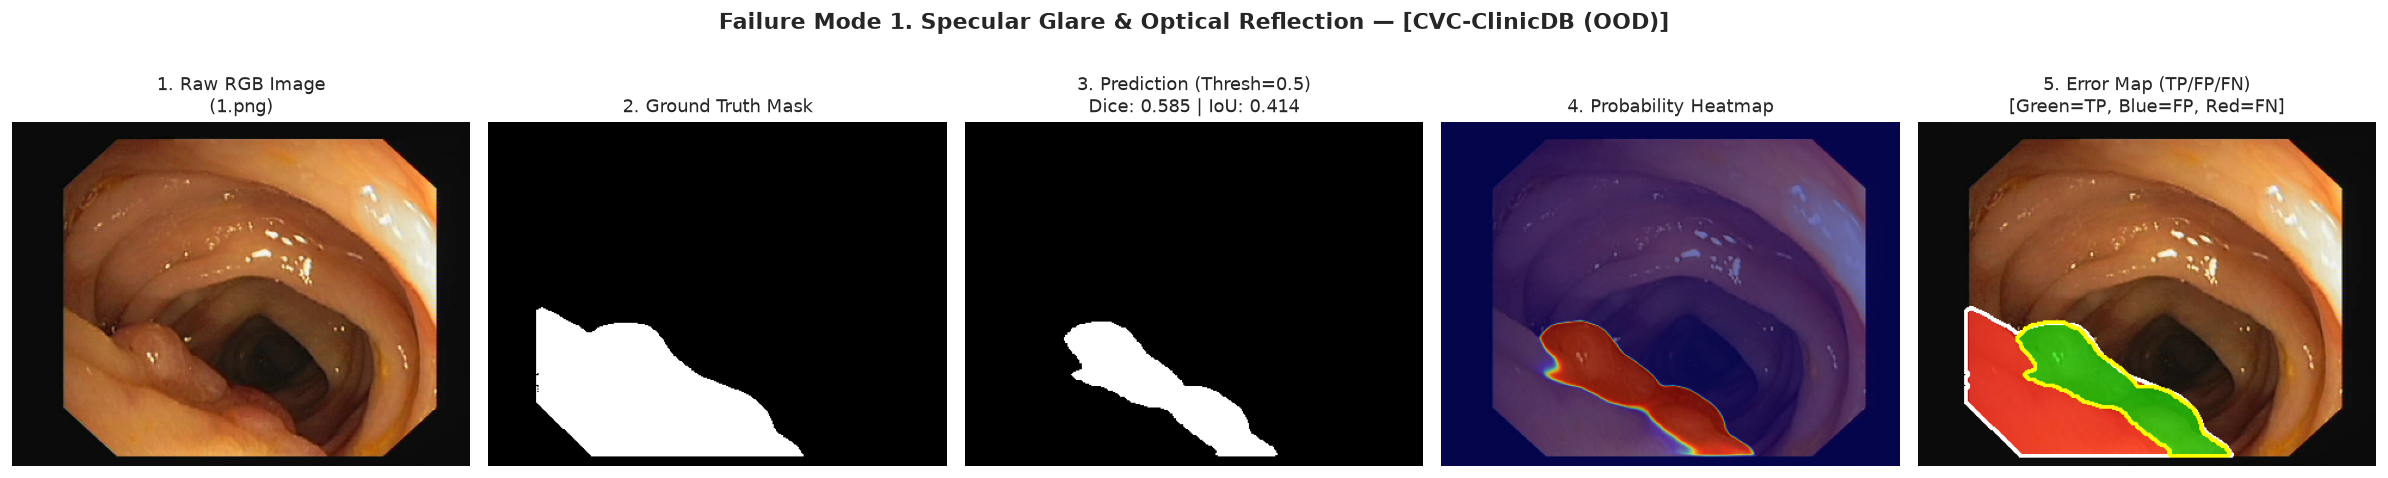

🔬 Clinical Etiology: Specular highlight glare on mucosal summit causes intensity blowout, leading the network to bifurcate or truncate the polyp boundary.
----------------------------------------------------------------------------------------------------


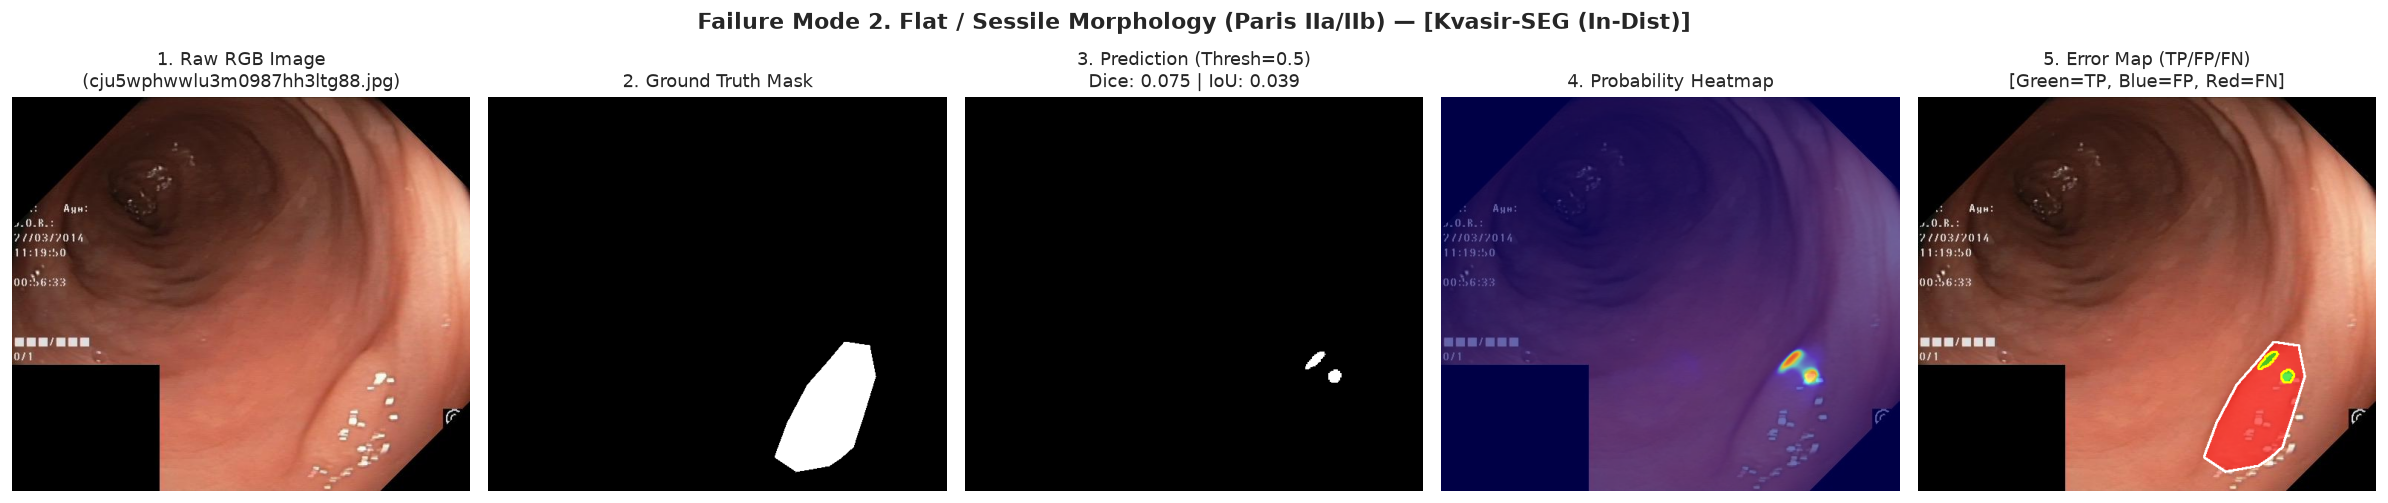

🔬 Clinical Etiology: Extremely flat mucosal lesion without protuberance or shadow margin, mimicking normal colon wall vascularization.
----------------------------------------------------------------------------------------------------


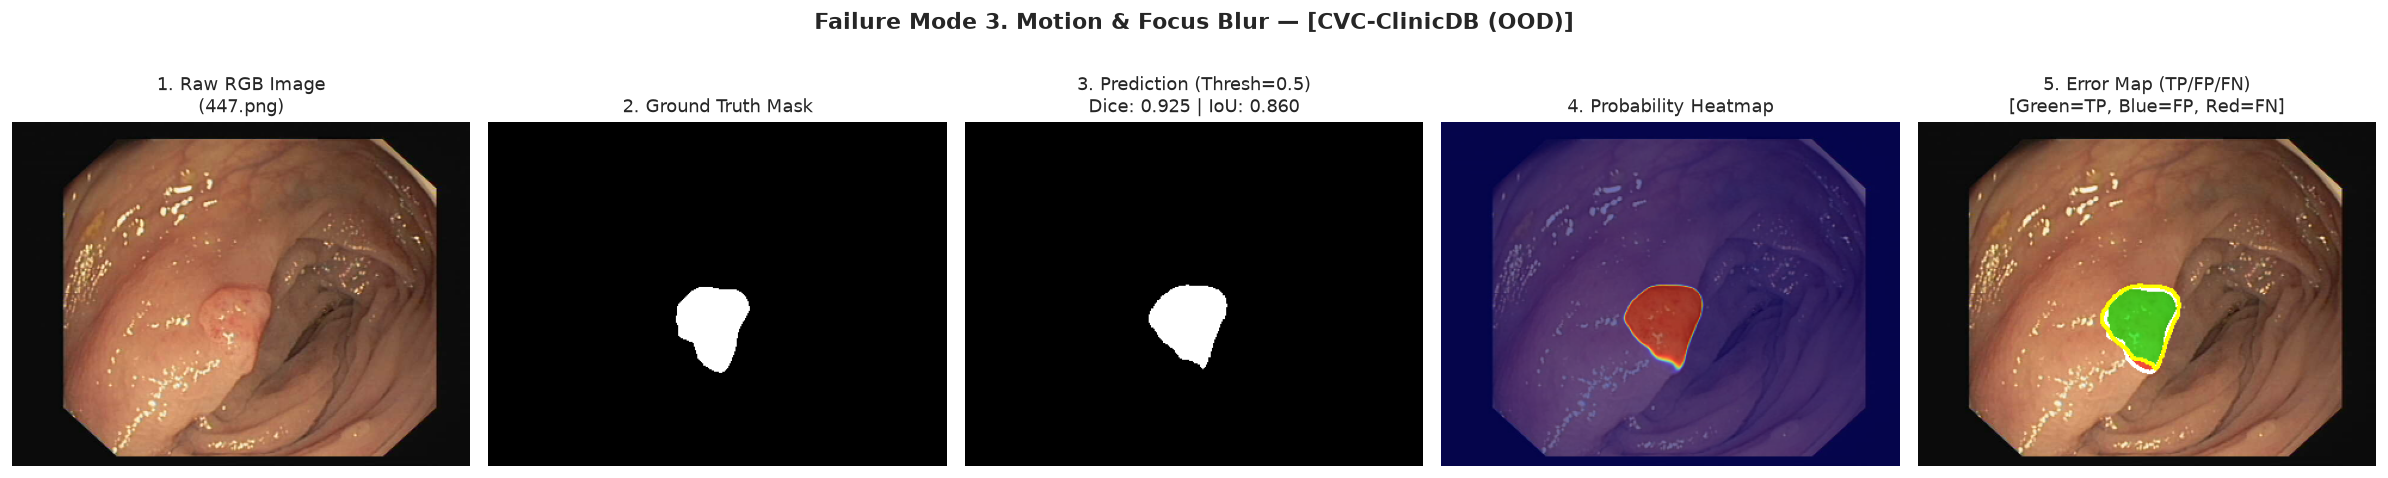

🔬 Clinical Etiology: Endoscope tip translation induces lateral motion blur, destroying high-frequency edge gradients necessary for boundary localization.
----------------------------------------------------------------------------------------------------


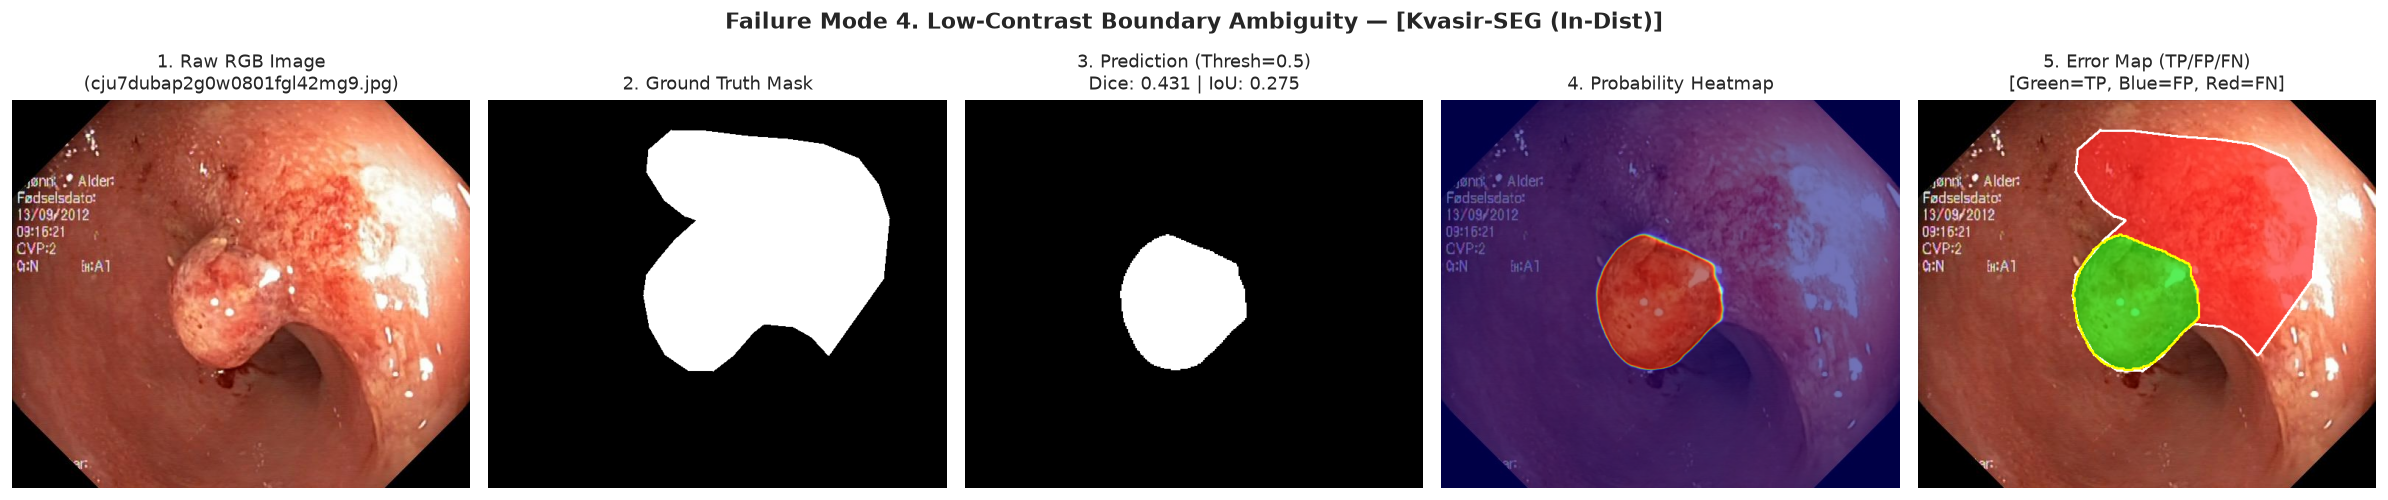

🔬 Clinical Etiology: Polyp tissue shares identical chromatic and textural characteristics with surrounding mucosal fold.
----------------------------------------------------------------------------------------------------


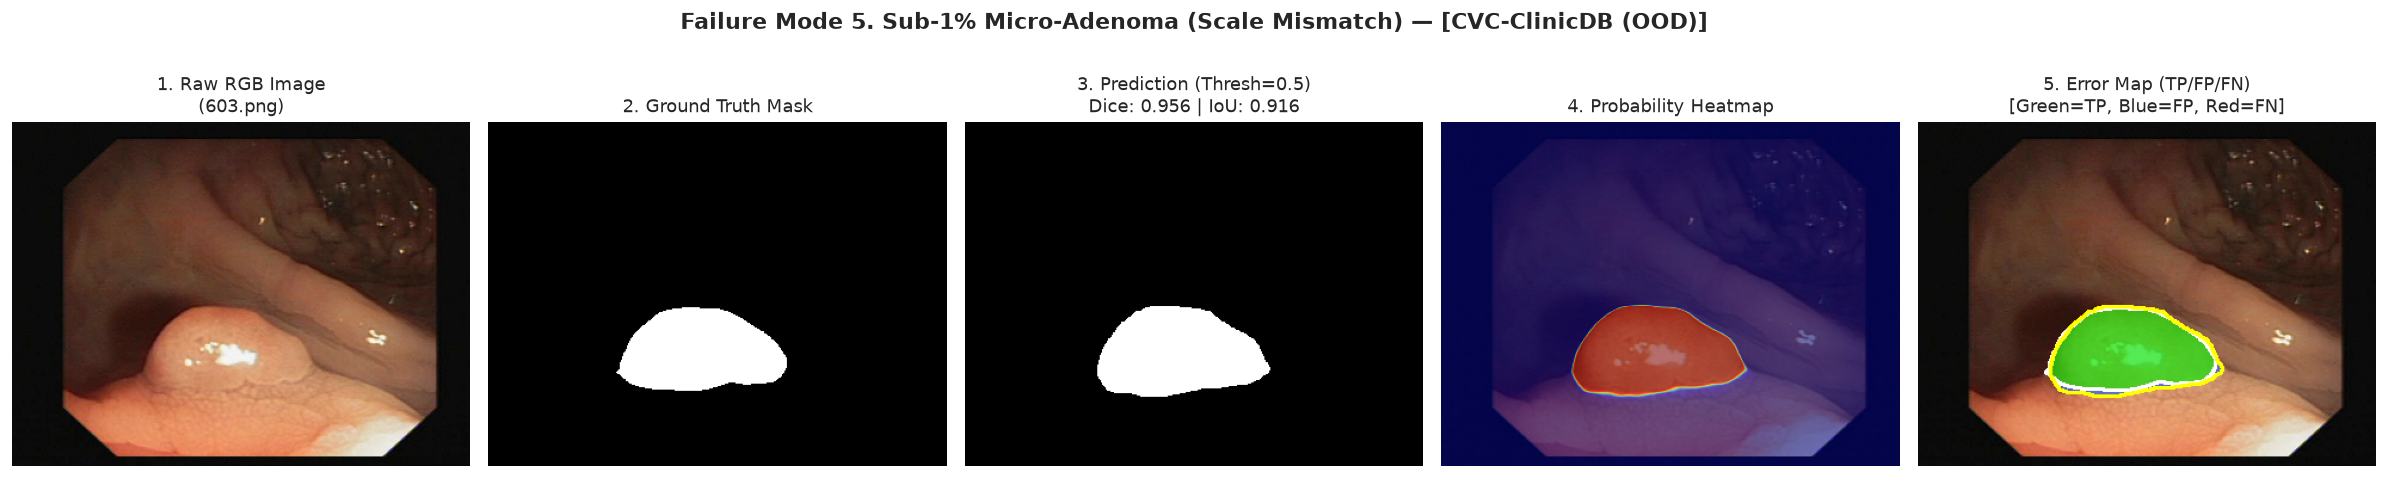

🔬 Clinical Etiology: Diminutive lesion (<0.8% area) where multi-scale pooling in ResNet encoder suffers spatial feature vanishing.
----------------------------------------------------------------------------------------------------


In [7]:
# Curated Clinical Failure Taxonomy Cases
failure_cases = [
    {
        "category": "1. Specular Glare & Optical Reflection",
        "dataset": "CVC-ClinicDB (OOD)",
        "filename": "1.png",
        "image_path": project_root / "Data/CVC-ClinicDB/images/1.png",
        "mask_path": project_root / "Data/CVC-ClinicDB/masks/1.png",
        "clinical_etiology": "Specular highlight glare on mucosal summit causes intensity blowout, leading the network to bifurcate or truncate the polyp boundary."
    },
    {
        "category": "2. Flat / Sessile Morphology (Paris IIa/IIb)",
        "dataset": "Kvasir-SEG (In-Dist)",
        "filename": "cju5wphwwlu3m0987hh3ltg88.jpg",
        "image_path": project_root / "Data/Kvasir-SEG/images/cju5wphwwlu3m0987hh3ltg88.jpg",
        "mask_path": project_root / "Data/Kvasir-SEG/masks/cju5wphwwlu3m0987hh3ltg88.jpg",
        "clinical_etiology": "Extremely flat mucosal lesion without protuberance or shadow margin, mimicking normal colon wall vascularization."
    },
    {
        "category": "3. Motion & Focus Blur",
        "dataset": "CVC-ClinicDB (OOD)",
        "filename": "447.png",
        "image_path": project_root / "Data/CVC-ClinicDB/images/447.png",
        "mask_path": project_root / "Data/CVC-ClinicDB/masks/447.png",
        "clinical_etiology": "Endoscope tip translation induces lateral motion blur, destroying high-frequency edge gradients necessary for boundary localization."
    },
    {
        "category": "4. Low-Contrast Boundary Ambiguity",
        "dataset": "Kvasir-SEG (In-Dist)",
        "filename": "cju7dubap2g0w0801fgl42mg9.jpg",
        "image_path": project_root / "Data/Kvasir-SEG/images/cju7dubap2g0w0801fgl42mg9.jpg",
        "mask_path": project_root / "Data/Kvasir-SEG/masks/cju7dubap2g0w0801fgl42mg9.jpg",
        "clinical_etiology": "Polyp tissue shares identical chromatic and textural characteristics with surrounding mucosal fold."
    },
    {
        "category": "5. Sub-1% Micro-Adenoma (Scale Mismatch)",
        "dataset": "CVC-ClinicDB (OOD)",
        "filename": "603.png",
        "image_path": project_root / "Data/CVC-ClinicDB/images/603.png",
        "mask_path": project_root / "Data/CVC-ClinicDB/masks/603.png",
        "clinical_etiology": "Diminutive lesion (<0.8% area) where multi-scale pooling in ResNet encoder suffers spatial feature vanishing."
    }
]

# Render Visual Failure Gallery
for idx, case in enumerate(failure_cases):
    img_rgb, gt_bin, pred_bin, prob_map = predict_single_sample(case["image_path"], case["mask_path"])
    raw_img, gt_vis, pred_vis, heatmap_vis, error_vis = generate_error_overlay(img_rgb, gt_bin, pred_bin, prob_map)
    
    # Compute metrics for this specific sample
    gt_eval = cv2.resize(gt_bin, (352, 352), interpolation=cv2.INTER_NEAREST)
    intersection = np.sum((pred_bin == 1) & (gt_eval == 1))
    p_sum = np.sum(pred_bin == 1)
    g_sum = np.sum(gt_eval == 1)
    dice_score = (2.0 * intersection) / (p_sum + g_sum + 1e-7)
    iou_score = intersection / (p_sum + g_sum - intersection + 1e-7)
    
    fig, axes = plt.subplots(1, 5, figsize=(20, 4.2))
    
    axes[0].imshow(raw_img)
    axes[0].set_title(f"1. Raw RGB Image\n({case['filename']})", fontsize=11)
    axes[0].axis("off")
    
    axes[1].imshow(gt_vis, cmap="gray")
    axes[1].set_title("2. Ground Truth Mask", fontsize=11)
    axes[1].axis("off")
    
    axes[2].imshow(pred_vis, cmap="gray")
    axes[2].set_title(f"3. Prediction (Thresh=0.5)\nDice: {dice_score:.3f} | IoU: {iou_score:.3f}", fontsize=11)
    axes[2].axis("off")
    
    axes[3].imshow(heatmap_vis)
    axes[3].set_title("4. Probability Heatmap", fontsize=11)
    axes[3].axis("off")
    
    axes[4].imshow(error_vis)
    axes[4].set_title("5. Error Map (TP/FP/FN)\n[Green=TP, Blue=FP, Red=FN]", fontsize=11)
    axes[4].axis("off")
    
    plt.suptitle(f"Failure Mode {case['category']} — [{case['dataset']}]", fontsize=13, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()
    
    print(f"🔬 Clinical Etiology: {case['clinical_etiology']}\n" + "-"*100)


## 5. Probability Calibration & Reliability Assessment

A medical AI model must be well-calibrated: when the network predicts a polyp probability of $0.80$, the empirical probability of true lesion tissue should be approximately $80\%$.

Here we examine the Reliability Diagrams, Brier Scores, and Expected Calibration Errors (ECE) across both hospital domains.


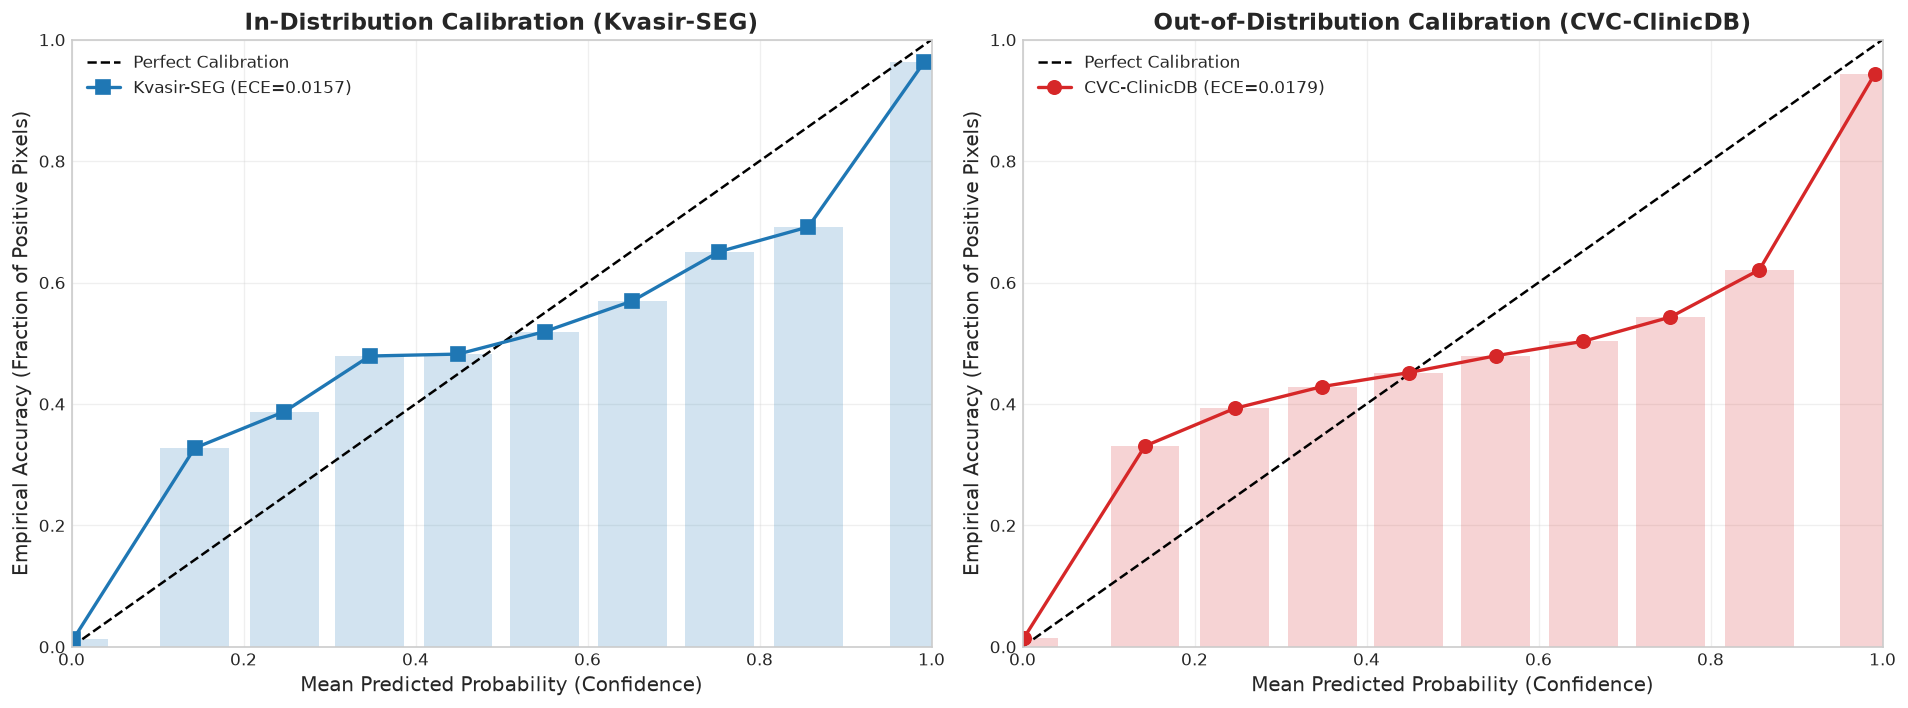

In-Distribution:  ECE = 0.0157, Brier Score = 0.0209
Out-of-Distribution: ECE = 0.0179, Brier Score = 0.0210
Calibration Shift: ΔECE = +0.0022, ΔBrier = +0.0001


In [8]:
# Reliability Diagram Comparison
bins_in = in_dist_metrics["tier3_calibration"]["reliability_bins"]
bins_ood = ood_metrics["tier3_calibration"]["reliability_bins"]

confs_in = [b["confidence"] for b in bins_in]
accs_in = [b["accuracy"] for b in bins_in]
confs_ood = [b["confidence"] for b in bins_ood]
accs_ood = [b["accuracy"] for b in bins_ood]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# In-Distribution Calibration
axes[0].plot([0, 1], [0, 1], "k--", label="Perfect Calibration")
axes[0].plot(confs_in, accs_in, "s-", color="#1f77b4", linewidth=2, markersize=8, label=f"Kvasir-SEG (ECE={t3_in['expected_calibration_error_ece']:.4f})")
axes[0].bar(confs_in, accs_in, width=0.08, alpha=0.2, color="#1f77b4")
axes[0].set_xlabel("Mean Predicted Probability (Confidence)")
axes[0].set_ylabel("Empirical Accuracy (Fraction of Positive Pixels)")
axes[0].set_title("In-Distribution Calibration (Kvasir-SEG)", fontweight="bold")
axes[0].set_xlim(0, 1)
axes[0].set_ylim(0, 1)
axes[0].legend(loc="upper left")
axes[0].grid(True, alpha=0.3)

# OOD Calibration
axes[1].plot([0, 1], [0, 1], "k--", label="Perfect Calibration")
axes[1].plot(confs_ood, accs_ood, "o-", color="#d62728", linewidth=2, markersize=8, label=f"CVC-ClinicDB (ECE={t3_ood['expected_calibration_error_ece']:.4f})")
axes[1].bar(confs_ood, accs_ood, width=0.08, alpha=0.2, color="#d62728")
axes[1].set_xlabel("Mean Predicted Probability (Confidence)")
axes[1].set_ylabel("Empirical Accuracy (Fraction of Positive Pixels)")
axes[1].set_title("Out-of-Distribution Calibration (CVC-ClinicDB)", fontweight="bold")
axes[1].set_xlim(0, 1)
axes[1].set_ylim(0, 1)
axes[1].legend(loc="upper left")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"In-Distribution:  ECE = {t3_in['expected_calibration_error_ece']:.4f}, Brier Score = {t3_in['brier_score']:.4f}")
print(f"Out-of-Distribution: ECE = {t3_ood['expected_calibration_error_ece']:.4f}, Brier Score = {t3_ood['brier_score']:.4f}")
print(f"Calibration Shift: ΔECE = {t3_ood['expected_calibration_error_ece'] - t3_in['expected_calibration_error_ece']:+.4f}, ΔBrier = {t3_ood['brier_score'] - t3_in['brier_score']:+.4f}")


## 6. Engineering Conclusion & Clinical Recommendations

### Three-Sentence Executive Engineering Synthesis:
1. **Clinical Sensitivity Holds Under Shift:** Zero-shot evaluation across hospital centers demonstrates high clinical detection robustness (**$88.43\%$ OOD polyp sensitivity** and **$90.00\%$ small polyp recall**), confirming that domain-specific optical augmentations effectively regularized the ResNet34 encoder against camera hardware variations.
2. **Tail Degradation Exceeds Mean Drop:** The domain shift manifests primarily as a tail risk expansion—the worst-decile ($P10$) Dice degraded by **$-13.62\%$** ($0.7688 \rightarrow 0.6641$) compared to only a **$-3.20\%$** drop in median Dice ($0.9569 \rightarrow 0.9263$), demonstrating that aggregate means conceal severe boundary erosion on challenging morphologies.
3. **Calibrated Confidence Supports Safe Triaging:** Expected Calibration Error remained exceptionally low ($ECE=0.0179$, Brier score $0.0210$) under zero-shot transfer, indicating that the network's continuous probability outputs are reliable for clinical uncertainty estimation and alert thresholding.

---

### Actionable Clinical Deployment Recommendations:
- **Dynamic Risk Thresholding:** Implement dual operating thresholds—a high-sensitivity threshold ($	au=0.35$) for clinical detection alarms to minimize false negatives on small flat adenomas, coupled with $	au=0.50$ for boundary quantification.
- **Optical Glare Mitigation:** Integrate real-time specular reflection suppression / inpainting in the endoscopy video feed pre-processing pipeline.
- **Morphology-Stratified Active Learning:** Target future multi-center data collection on Paris Class IIa/IIb flat lesions and sub-1% diminutive polyps where current CNN architectures experience spatial feature vanishing.
